#Online Retail Analysis

**Dataset:** Online Retail (UCI Machine Learning Repository)  
**Periode:** 2010–2011  
**Tujuan:** Menganalisis pola transaksi dan mensegmentasi customer menggunakan metode RFM (Recency, Frequency, Monetary) untuk mendukung strategi marketing yang lebih tepat sasaran.

---

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load Data

Memuat dataset dari Google Drive dan melakukan inspeksi awal untuk memahami struktur dan kualitas data.

In [53]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/Online_Retail.csv', encoding= 'latin1')
display(df.head())
df.info()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 2. Data Cleaning

Beberapa langkah pembersihan dilakukan sebelum analisis:
- Menghapus baris dengan `CustomerID` kosong (transaksi anonim tidak bisa dianalisis per customer)
- Memfilter `Quantity` dan `UnitPrice` yang bernilai negatif atau nol (kemungkinan retur/kesalahan input)
- Membuat kolom `Revenue` = `Quantity × UnitPrice`

In [54]:
#Ubah InvoiceDate ke format DateTime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['UnitPrice']>0)]
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['Revenue'] = df_clean['Quantity']*df_clean['UnitPrice']
df_clean.info()
display(df_clean.head())

/tmp/ipykernel_16937/2867813508.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  object        
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 30.4+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Tren Revenue Bulanan

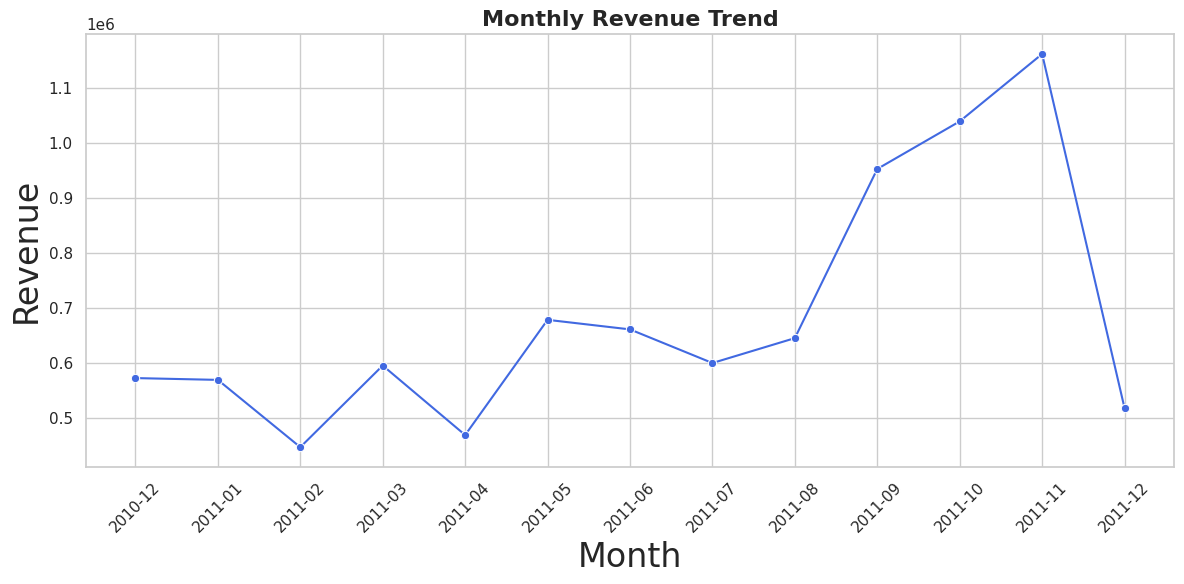

In [56]:
df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('MonthYear')['Revenue'].sum().reset_index()
monthly_revenue['MonthYear'] = monthly_revenue['MonthYear'].astype(str)
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue, x = 'MonthYear', y= 'Revenue', marker = 'o', color = 'royalblue')
plt.title ("Monthly Revenue Trend", fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 24)
plt.ylabel('Revenue', fontsize = 24)
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

### 3.2 Revenue per Negara

Mayoritas transaksi berasal dari United Kingdom sebagai pasar utama. Berikut 10 negara dengan kontribusi revenue tertinggi.

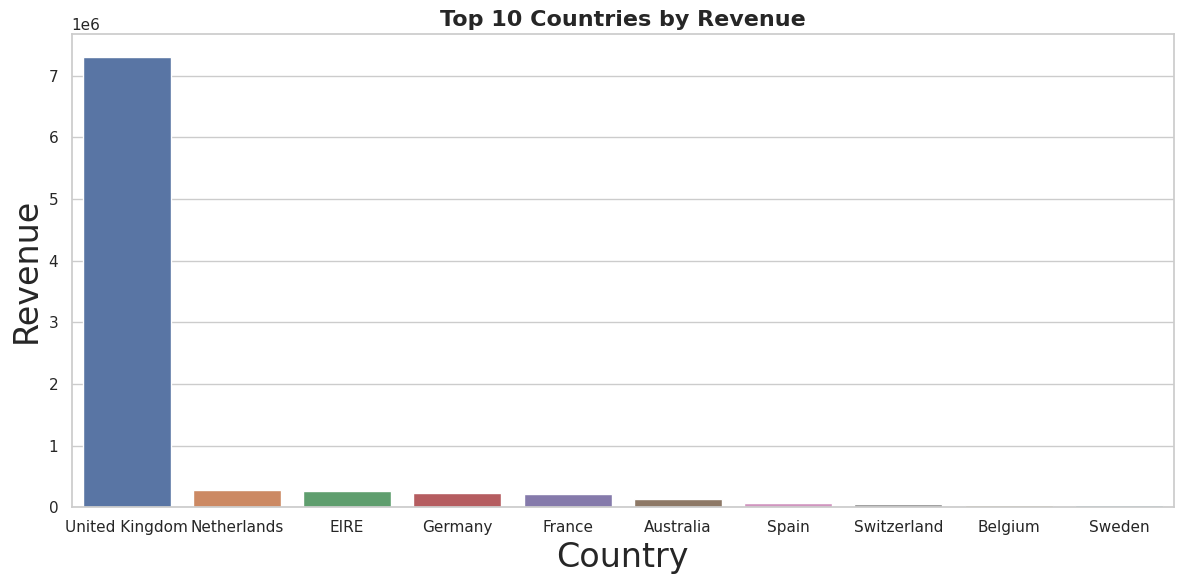

In [57]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().reset_index()
top10_countries = country_revenue.sort_values(by='Revenue', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10_countries, x='Country', y = 'Revenue', hue = 'Country', legend = False)

plt.title('Top 10 Countries by Revenue', fontsize = 16, fontweight = 'bold')
plt.xlabel('Country', fontsize = 24)
plt.ylabel('Revenue', fontsize = 24)

plt.tight_layout()
plt.show()

### 3.3 Pola Waktu Transaksi

Mengidentifikasi hari dan jam dengan volume transaksi tertinggi untuk mendukung keputusan operasional seperti jadwal promosi.

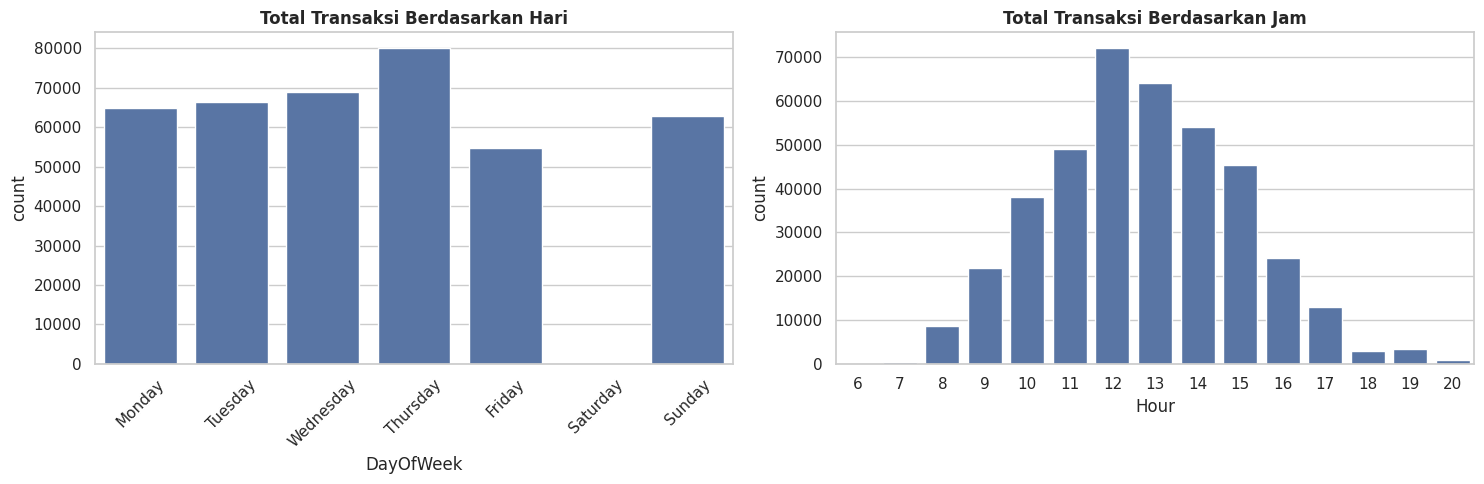

In [58]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

DayByOrder = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_clean, x = 'DayOfWeek', order = DayByOrder, ax=axes[0])
axes[0].set_title('Total Transaksi Berdasarkan Hari', fontweight='bold')
axes[0].tick_params(axis='x', rotation = 45)

sns.countplot(data=df_clean, x = 'Hour', ax=axes[1])
axes[1].set_title('Total Transaksi Berdasarkan Jam', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Pemetaan Customer

Visualisasi hubungan antara frekuensi transaksi dan total pengeluaran per customer. Garis merah menunjukkan ambang batas top 5% spender.

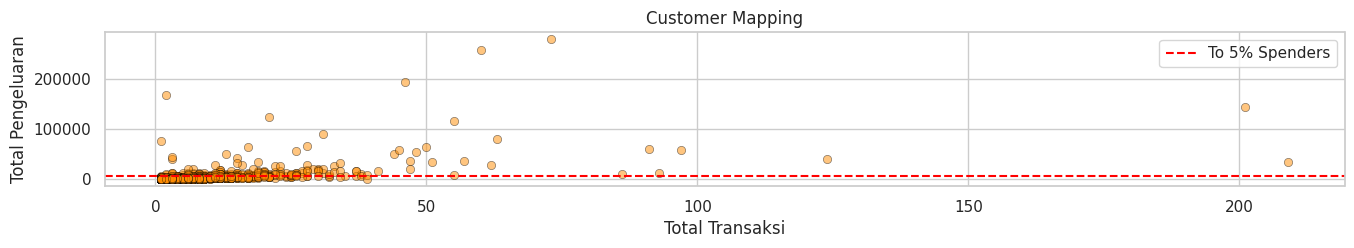

,CustomerID,Total_Transaksi,Total_Revenue
1689,14646,73,280206.02
4201,18102,60,259657.30
3728,17450,46,194550.79
3008,16446,2,168472.50
1879,14911,201,143825.06


In [59]:
customer_behavior = df_clean.groupby('CustomerID').agg(
    Total_Transaksi = ('InvoiceNo', 'nunique'),
    Total_Revenue = ('Revenue', 'sum')
).reset_index()

plt.figure(figsize=(16,2))
sns.scatterplot(data=customer_behavior, x ='Total_Transaksi', y ='Total_Revenue', alpha=0.5, color ='darkorange', edgecolor='black')

plt.title('Customer Mapping')
plt.xlabel('Total Transaksi')
plt.ylabel('Total Pengeluaran')

plt.axhline(y=customer_behavior['Total_Revenue'].quantile(0.95), color = 'red', linestyle='--', label = 'To 5% Spenders')
plt.legend()
plt.show()

vip = customer_behavior.sort_values(by='Total_Revenue', ascending = False).head(5)
display(vip)

## 4. RFM Analysis

RFM adalah metode segmentasi customer berdasarkan tiga dimensi:

| Dimensi | Definisi |
|---|---|
| **Recency** | Seberapa baru customer melakukan transaksi (dalam hari) |
| **Frequency** | Seberapa sering customer bertransaksi |
| **Monetary** | Seberapa besar total pengeluaran customer |

Setiap dimensi diberi skor 1–5, lalu customer dikelompokkan ke dalam segmen berdasarkan kombinasi skornya.

In [60]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference Date: ",reference_date)

Reference Date:  2011-12-10 12:50:00


In [61]:
rfm = df_clean.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('Revenue', 'sum')
).reset_index()

print(rfm.shape)
rfm.describe()

(4338, 4)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [62]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

In [63]:
def segment_customer(row):
  r,f,m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
  if r >= 4 and f>=4:
    return 'Champions'
  elif r>=3 and f >= 3:
    return 'Loyal Customers'
  elif r >= 4 and f <= 2 :
    return 'New Customers'
  elif r <= 2 and f >= 3:
    return 'At Risk'
  elif r <= 2 and f <= 2:
    return 'Lost'
  else:
    return 'Potential Loyalist'

rfm['Segment'] = rfm.apply(segment_customer,axis = 1)
rfm['Segment'].value_counts()

,count
Segment,
Champions,1139
Lost,1065
Loyal Customers,821
At Risk,643
Potential Loyalist,351
New Customers,319


### 4.1 Hasil Segmentasi

**Insight:**
- **Champions (1.139)** — Customer terbaik: sering beli, baru-baru ini aktif, pengeluaran tinggi. Prioritaskan reward dan loyalty program.
- **Lost (1.065)** — Sudah lama tidak aktif dan frekuensi rendah. Pertimbangkan win-back campaign atau abaikan untuk efisiensi budget.
- **Loyal Customers (821)** — Aktif dan konsisten, namun belum di level Champions. Dorong dengan upselling.
- **At Risk (643)** — Dulu aktif, sekarang mulai menghilang. Perlu re-engagement segera sebelum benar-benar churn.
- **New Customers (319)** — Baru bergabung. Fokus pada onboarding experience agar mereka kembali lagi.

/tmp/ipykernel_16937/1748945253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='viridis')


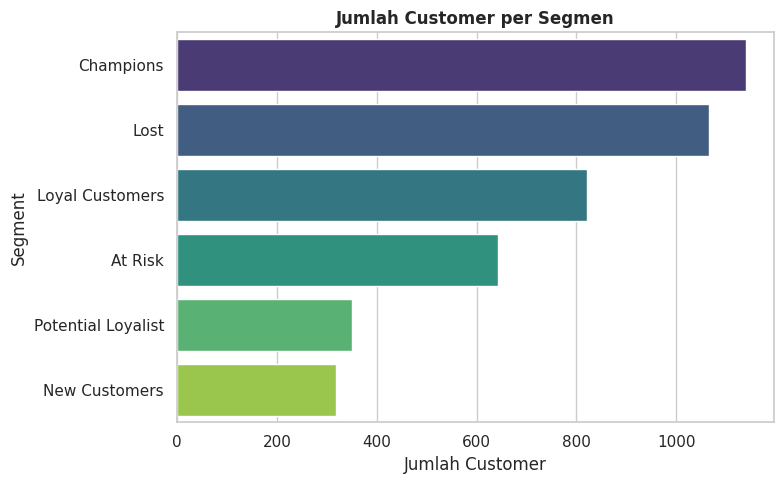

In [64]:
plt.figure(figsize=(8, 5))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='viridis')
plt.title('Jumlah Customer per Segmen', fontweight='bold')
plt.xlabel('Jumlah Customer')
plt.tight_layout()
plt.show()

/tmp/ipykernel_16937/4165468223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_monetary.values, y=segment_monetary.index, palette='magma')


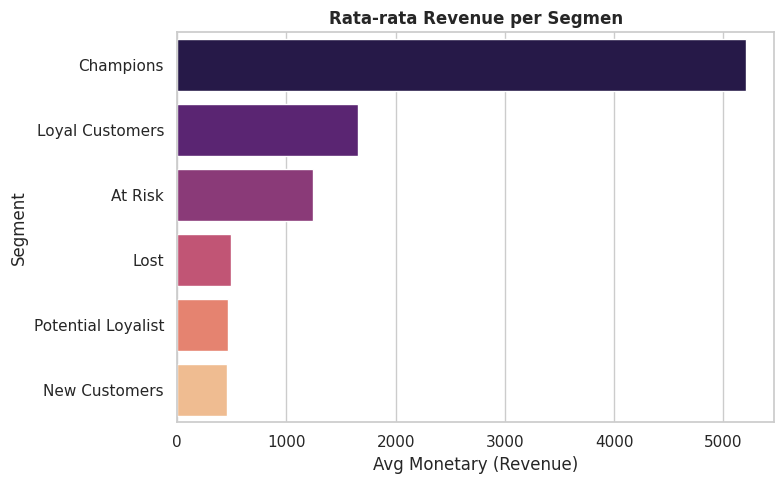

In [65]:
# Plot 2 - Rata-rata revenue per segmen
plt.figure(figsize=(8, 5))
segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
sns.barplot(x=segment_monetary.values, y=segment_monetary.index, palette='magma')
plt.title('Rata-rata Revenue per Segmen', fontweight='bold')
plt.xlabel('Avg Monetary (Revenue)')
plt.tight_layout()
plt.show()